# 🔍 Notebook 3 — Unsupervised Clustering: What Do the Defect Labels Mean?

**Purpose:** Use K-Means clustering on PLC sensor data to discover what each `DIF_TIPO_1–6` label represents physically — building a data dictionary from sensor evidence.

**Run after:** `02_EDA_PLC_&_Merge.ipynb`

**Input:** `plc_defect_merged.csv` — 298,851 rows × 120 cols (flagged coils already removed)

**Output:** `merged_with_clusters.csv` — full dataset with CLUSTER column added (121 cols)

---

### Strategy
| Step | What | Why |
|------|------|-----|
| Aggregate to coil level | 298,851 rows → 1,240 coils | Avoids autocorrelation between neighbouring 7m rows on same coil |
| StandardScaler | Centre each sensor to mean=0, std=1 | Prevents high-range sensors (e.g. temperature) dominating distance calculations |
| PCA (212 features → 35 components) | Dimensionality reduction | 87.3% variance explained — removes 128 correlated sensor pairs found in EDA |
| K-Means (K=6) | Clustering | HDBSCAN attempted but sklearn 1.6 version conflict — K-Means used instead |
| Cross-reference clusters vs DIF_TIPO | Interpretation | Defect flags used ONLY after clustering — never as features |

---

### Key finding
Defect labels do not map cleanly to distinct sensor conditions.
Clusters separate coils by **defect severity**, not defect type.
Two key process drivers identified: `LASER_RAFF_1` and `AIR_Z5/GAS_Z5`.
See Step 8 for full data dictionary and Step 9 for Phase 2 recommendations.

## ⚙️ Configuration

In [1]:
# ── Update this path ──────────────────────────────────────────────────────────
MERGED_PATH = "../data/cleaned/plc_defect_merged.csv"
OUTPUT_DIR  = "../data/final"

DEFECT_COLS = ['DIF_TIPO_1', 'DIF_TIPO_2', 'DIF_TIPO_3',
               'DIF_TIPO_4', 'DIF_TIPO_5', 'DIF_TIPO_6']

# Columns that are NOT sensors
META_COLS = ['COIL', 'MT', 'DATE', 'TIME_START_PROCESS',
             'IS_TAIL_FINISHING', 'IS_TAIL_RAFFINATION',
             'IS_TAIL_PICKLING', 'HAS_DEFECT']


# PCA: number of components to keep
N_PCA_COMPONENTS = 20

# HDBSCAN: tune these if clusters don't look right
# min_cluster_size: minimum number of coils to form a cluster
# min_samples: higher = more conservative, more noise points
HDBSCAN_MIN_CLUSTER_SIZE = 5
HDBSCAN_MIN_SAMPLES      = 2

print('✅ Configuration set')

✅ Configuration set


In [2]:
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'✅ Output dir ready: {OUTPUT_DIR}')

✅ Output dir ready: ../data/final


In [3]:
import sys, numpy, sklearn, pandas, hdbscan
print(sys.executable)
print("numpy:", numpy.__version__)
print("sklearn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("hdbscan imported successfully")


c:\Users\IIsra\anaconda3\envs\ml-hdbscan\python.exe
numpy: 1.26.4
sklearn: 1.8.0
pandas: 3.0.1
hdbscan imported successfully


## 📦 Imports & Setup

In [4]:
!pip install hdbscan

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Try HDBSCAN — fall back to DBSCAN if not installed
try:
    import hdbscan
    USE_HDBSCAN = True
    print('✅ HDBSCAN available')
except ImportError:
    from sklearn.cluster import DBSCAN
    USE_HDBSCAN = False
    print('⚠️  HDBSCAN not installed — using DBSCAN as fallback')
    print('   Install with: pip install hdbscan')

pd.set_option('display.max_columns', None)
print(f'pandas {pd.__version__} | numpy {np.__version__}')

✅ HDBSCAN available
pandas 3.0.1 | numpy 1.26.4


## Step 1 — Load Merged Data

In [9]:
df = pd.read_csv(MERGED_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')

# Flagged coils were already removed before saving — no filter needed
df_clean = df.copy()
print(f'Rows ready for clustering: {df_clean.shape[0]:,}')

# Identify sensor columns
sensor_cols = [c for c in df_clean.columns 
               if c not in META_COLS + DEFECT_COLS]
print(f'Sensor columns found: {len(sensor_cols)}')
print(f'First 5: {sensor_cols[:5]}')

Loaded: 298,851 rows × 120 cols
Rows ready for clustering: 298,851
Sensor columns found: 106
First 5: ['SPEED_PROCESS', 'TEMP_Z1', 'TEMP_Z2', 'TEMP_Z3', 'TEMP_Z4']


In [10]:
print("Meta cols found in dataset:")
for c in META_COLS:
    status = "✅" if c in df_clean.columns else "❌ MISSING"
    print(f"  {status} {c}")

print(f"\nDefect cols found in dataset:")
for c in DEFECT_COLS:
    status = "✅" if c in df_clean.columns else "❌ MISSING"
    print(f"  {status} {c}")

print(f"\nTotal cols:   {df_clean.shape[1]}")
print(f"Meta cols:    {len([c for c in META_COLS if c in df_clean.columns])}")
print(f"Defect cols:  {len([c for c in DEFECT_COLS if c in df_clean.columns])}")
print(f"Sensor cols:  {len(sensor_cols)}")
print(f"Accounted for: {len([c for c in META_COLS if c in df_clean.columns]) + len([c for c in DEFECT_COLS if c in df_clean.columns]) + len(sensor_cols)}")

Meta cols found in dataset:
  ✅ COIL
  ✅ MT
  ✅ DATE
  ✅ TIME_START_PROCESS
  ✅ IS_TAIL_FINISHING
  ✅ IS_TAIL_RAFFINATION
  ✅ IS_TAIL_PICKLING
  ✅ HAS_DEFECT

Defect cols found in dataset:
  ✅ DIF_TIPO_1
  ✅ DIF_TIPO_2
  ✅ DIF_TIPO_3
  ✅ DIF_TIPO_4
  ✅ DIF_TIPO_5
  ✅ DIF_TIPO_6

Total cols:   120
Meta cols:    8
Defect cols:  6
Sensor cols:  106
Accounted for: 120


## Step 2 — Aggregate to Coil Level
Reduce 299K rows → one row per coil by computing mean + std for each sensor.  
This removes autocorrelation between neighbouring rows on the same coil.

In [11]:
# Build aggregation dict
agg_funcs = {col: ['mean', 'std'] for col in sensor_cols}
agg_funcs.update({col: 'max' for col in DEFECT_COLS})

coil_df = df_clean.groupby('COIL').agg(agg_funcs)
coil_df.columns = ['_'.join(c).strip('_') for c in coil_df.columns]
coil_df = coil_df.reset_index()

print(f'Coil-level shape: {coil_df.shape[0]:,} coils × {coil_df.shape[1]} cols')

# Separate features from labels
defect_label_cols = [c for c in coil_df.columns if c.startswith('DIF_TIPO')]
feature_cols      = [c for c in coil_df.columns
                     if c not in ['COIL'] + defect_label_cols]

X = coil_df[feature_cols].fillna(coil_df[feature_cols].median())
y = coil_df[defect_label_cols]

print(f'Feature matrix X: {X.shape[0]} coils × {X.shape[1]} features')
print(f'Label matrix y:   {y.shape[0]} coils × {y.shape[1]} defect types')

# Show defect prevalence at coil level
print('\nDefect prevalence at coil level:')
for col in defect_label_cols:
    n = y[col].sum()
    print(f'  {col}: {n} coils ({n/len(y)*100:.1f}%)')

Coil-level shape: 1,240 coils × 219 cols
Feature matrix X: 1240 coils × 212 features
Label matrix y:   1240 coils × 6 defect types

Defect prevalence at coil level:
  DIF_TIPO_1_max: 66 coils (5.3%)
  DIF_TIPO_2_max: 71 coils (5.7%)
  DIF_TIPO_3_max: 429 coils (34.6%)
  DIF_TIPO_4_max: 247 coils (19.9%)
  DIF_TIPO_5_max: 41 coils (3.3%)
  DIF_TIPO_6_max: 45 coils (3.6%)


## Step 3 — Scale + PCA
StandardScaler centres each sensor to mean=0 std=1.  
PCA reduces 120 features (60 sensors × mean/std) to 20 components.

Variance explained by 35 components: 87.3%


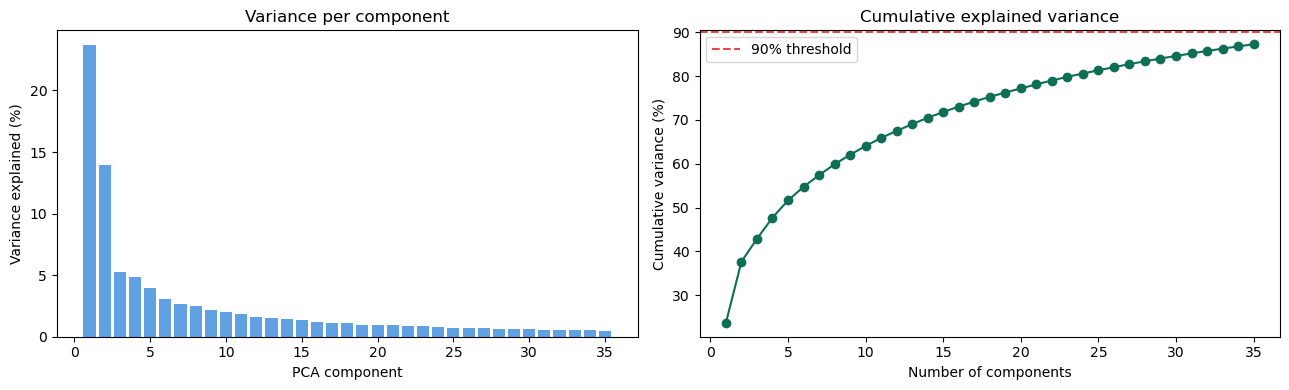

In [12]:
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)

N_PCA_COMPONENTS = 35
pca       = PCA(n_components=N_PCA_COMPONENTS, random_state=42)
X_pca     = pca.fit_transform(X_scaled)

explained_cumulative = pca.explained_variance_ratio_.cumsum()
print(f'Variance explained by {N_PCA_COMPONENTS} components: '
      f'{explained_cumulative[-1]*100:.1f}%')

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, N_PCA_COMPONENTS + 1),
            pca.explained_variance_ratio_ * 100,
            color='#378ADD', alpha=0.8)
axes[0].set_xlabel('PCA component')
axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('Variance per component')

axes[1].plot(range(1, N_PCA_COMPONENTS + 1),
             explained_cumulative * 100,
             marker='o', color='#0F6E56')
axes[1].axhline(90, color='#E24B4A', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Cumulative explained variance')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 4 — HDBSCAN Clustering

**Important:** defect flags are NOT used as features here.  
We cluster purely on sensor PCA components, then compare clusters to defect labels afterwards.

In [13]:
!pip install scikit-learn==1.5.2 --force-reinstall

  Using cached scikit_learn-1.5.2-cp311-cp311-win_amd64.whl.metadata (13 kB)
  Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp311-cp311-win_amd64.whl (11.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl (12.6 MB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

  Attempting uninstall: threadpoolctl

    Found existing installation: threadpoolctl 3.6.0

    Uninstalling threadpoolctl-3.6.0:

   ---------------------------------------- 0/5 [threadpoolctl]
   ---------------------------------------- 0/5 [threadpoolctl]
   ---------------------------------------- 0/5 [threadpoolctl]
   --------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [14]:
!pip install hdbscan --force-reinstal

  Using cached hdbscan-0.8.41-cp311-cp311-win_amd64.whl.metadata (15 kB)
  Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached hdbscan-0.8.41-cp311-cp311-win_amd64.whl (687 kB)
Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl (12.6 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

  Attempting uninstall: threadpoolctl

    Found existing installation: threadpoolctl 3.6.0

    Uninstalling threadpoolctl-3.6.0:

   ---------------------------------------- 0/6 [threadpoolctl]
   -------------

In [15]:
import hdbscan
import time

# Force parameters here directly — bypasses config cell issue
MIN_CLUSTER_SIZE = 5
MIN_SAMPLES      = 2

t0 = time.time()

try:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric='euclidean',
        cluster_selection_method='eom',
        core_dist_n_jobs=1  # avoids some version issues
    )
    labels = clusterer.fit_predict(X_pca)
    print('✅ HDBSCAN complete')
except Exception as e:
    print(f'❌ HDBSCAN error: {e}')
    labels = None

if labels is not None:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    print(f'Time:           {time.time()-t0:.1f}s')
    print(f'Clusters found: {n_clusters}')
    print(f'Noise coils:    {n_noise} ({n_noise/len(coil_df)*100:.1f}%)')
    print('\nCluster sizes:')
    for cid, count in pd.Series(labels).value_counts().sort_index().items():
        label = 'NOISE' if cid == -1 else f'Cluster {cid}'
        print(f'  {label}: {count} coils')

✅ HDBSCAN complete
Time:           0.5s
Clusters found: 4
Noise coils:    55 (4.4%)

Cluster sizes:
  NOISE: 55 coils
  Cluster 0: 8 coils
  Cluster 1: 5 coils
  Cluster 2: 5 coils
  Cluster 3: 1167 coils


In [16]:
print("Defect prevalence per cluster:\n")
print("Defect prevalence per cluster:\n")

# Ensure we have cluster labels stored on the coil-level dataframe
if 'CLUSTER' not in coil_df.columns:
    coil_df['CLUSTER'] = labels

for cid in sorted(coil_df['CLUSTER'].unique()):
    mask   = coil_df['CLUSTER'] == cid
    subset = y[mask.values]
    n      = mask.sum()
    label  = 'NOISE' if cid == -1 else f'Cluster {cid}'
    defect_str = '  '.join([f'{c.replace("_max","")}: {subset[c].mean()*100:.0f}%' 
                             for c in defect_label_cols])
    print(f'{label} (n={n}):  {defect_str}')

Defect prevalence per cluster:

Defect prevalence per cluster:

NOISE (n=55):  DIF_TIPO_1: 0%  DIF_TIPO_2: 4%  DIF_TIPO_3: 22%  DIF_TIPO_4: 7%  DIF_TIPO_5: 2%  DIF_TIPO_6: 0%
Cluster 0 (n=8):  DIF_TIPO_1: 0%  DIF_TIPO_2: 0%  DIF_TIPO_3: 38%  DIF_TIPO_4: 38%  DIF_TIPO_5: 0%  DIF_TIPO_6: 0%
Cluster 1 (n=5):  DIF_TIPO_1: 0%  DIF_TIPO_2: 20%  DIF_TIPO_3: 20%  DIF_TIPO_4: 0%  DIF_TIPO_5: 0%  DIF_TIPO_6: 0%
Cluster 2 (n=5):  DIF_TIPO_1: 0%  DIF_TIPO_2: 0%  DIF_TIPO_3: 0%  DIF_TIPO_4: 0%  DIF_TIPO_5: 0%  DIF_TIPO_6: 0%
Cluster 3 (n=1167):  DIF_TIPO_1: 6%  DIF_TIPO_2: 6%  DIF_TIPO_3: 35%  DIF_TIPO_4: 21%  DIF_TIPO_5: 3%  DIF_TIPO_6: 4%


In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)
coil_df['CLUSTER'] = labels

print('Cluster sizes:')
for cid, count in pd.Series(labels).value_counts().sort_index().items():
    print(f'  Cluster {cid}: {count} coils')

Cluster sizes:
  Cluster 0: 22 coils
  Cluster 1: 101 coils
  Cluster 2: 1 coils
  Cluster 3: 406 coils
  Cluster 4: 407 coils
  Cluster 5: 303 coils


In [18]:
print("Defect prevalence per cluster:\n")
for cid in sorted(coil_df['CLUSTER'].unique()):
    mask   = coil_df['CLUSTER'] == cid
    subset = y[mask.values]
    n      = mask.sum()
    defect_str = '  '.join([f'{c.replace("_max","").replace("DIF_","")}: {subset[c].mean()*100:.0f}%' 
                             for c in defect_label_cols])
    print(f'Cluster {cid} (n={n}):  {defect_str}')

Defect prevalence per cluster:

Cluster 0 (n=22):  TIPO_1: 0%  TIPO_2: 0%  TIPO_3: 14%  TIPO_4: 14%  TIPO_5: 0%  TIPO_6: 0%
Cluster 1 (n=101):  TIPO_1: 3%  TIPO_2: 7%  TIPO_3: 33%  TIPO_4: 16%  TIPO_5: 3%  TIPO_6: 2%
Cluster 2 (n=1):  TIPO_1: 0%  TIPO_2: 0%  TIPO_3: 0%  TIPO_4: 0%  TIPO_5: 0%  TIPO_6: 0%
Cluster 3 (n=406):  TIPO_1: 4%  TIPO_2: 4%  TIPO_3: 31%  TIPO_4: 16%  TIPO_5: 3%  TIPO_6: 2%
Cluster 4 (n=407):  TIPO_1: 10%  TIPO_2: 8%  TIPO_3: 50%  TIPO_4: 30%  TIPO_5: 3%  TIPO_6: 5%
Cluster 5 (n=303):  TIPO_1: 2%  TIPO_2: 4%  TIPO_3: 21%  TIPO_4: 13%  TIPO_5: 4%  TIPO_6: 4%


In [19]:
mean_sensor_cols = [c for c in feature_cols if c.endswith('_mean')]

print("Top 5 sensors differentiating each cluster from overall average:\n")
overall_mean = coil_df[mean_sensor_cols].mean()

for cid in sorted(coil_df['CLUSTER'].unique()):
    mask         = coil_df['CLUSTER'] == cid
    cluster_mean = coil_df[mask][mean_sensor_cols].mean()
    pct_diff     = ((cluster_mean - overall_mean) / (overall_mean.abs() + 1e-6)) * 100
    top5         = pct_diff.abs().nlargest(5)
    
    print(f'Cluster {cid} (n={mask.sum()}):')
    for sensor, _ in top5.items():
        val       = pct_diff[sensor]
        direction = '▲' if val > 0 else '▼'
        clean     = sensor.replace('_mean', '')
        print(f'  {direction} {clean:<35} {abs(val):.1f}% {"higher" if val > 0 else "lower"}')
    print()

Top 5 sensors differentiating each cluster from overall average:

Cluster 0 (n=22):
  ▲ AIR_CH4_2                           106.6% higher
  ▲ AIR_CH4_1                           87.6% higher
  ▲ FRN_PHF_PRESSURE                    49.3% higher
  ▲ AIR_CH4_3                           45.5% higher
  ▼ GAS_Z3_1                            40.7% lower

Cluster 1 (n=101):
  ▲ PRES_ZONA1_MEASURED                 129.1% higher
  ▲ PRES_ZONA2_MEASURED                 59.2% higher
  ▼ FILL_FORZA                          21.6% lower
  ▼ EXT_1                               15.1% lower
  ▼ FRN_PHF_PRESSURE                    14.7% lower

Cluster 2 (n=1):
  ▲ FRN_PHF_PRESSURE                    121.1% higher
  ▼ GAS_Z3_1                            96.8% lower
  ▼ AIR_Z3_1                            93.5% lower
  ▼ AIR_Z3_2                            92.6% lower
  ▼ FILL_ALL                            91.1% lower

Cluster 3 (n=406):
  ▼ LASER_RAFF_1                        50.1% lower
  ▼ LASER_RAFF_9

## Step 5 — Interpret: Which Defect Types Dominate Each Cluster?
This is the key table — it tells you what each cluster *is* in defect terms.

In [21]:
print("Defect prevalence per cluster:\n")
rows = []
for cid in sorted(coil_df['CLUSTER'].unique()):
    mask   = coil_df['CLUSTER'] == cid
    subset = y[mask.values]
    n      = mask.sum()
    row    = {'Cluster': f'Cluster {cid}', 'N coils': n}
    for col in defect_label_cols:
        row[col.replace('_max','').replace('DIF_','')] = f"{subset[col].mean()*100:.0f}%"
    rows.append(row)

interp_df = pd.DataFrame(rows).set_index('Cluster')
display(interp_df)

Defect prevalence per cluster:



,N coils,TIPO_1,TIPO_2,TIPO_3,TIPO_4,TIPO_5,TIPO_6
Cluster,,,,,,,
Cluster 0,22,0%,0%,14%,14%,0%,0%
Cluster 1,101,3%,7%,33%,16%,3%,2%
Cluster 2,1,0%,0%,0%,0%,0%,0%
Cluster 3,406,4%,4%,31%,16%,3%,2%
Cluster 4,407,10%,8%,50%,30%,3%,5%
Cluster 5,303,2%,4%,21%,13%,4%,4%


## Step 6 — Top Discriminating Sensors Per Cluster
For each cluster, which sensors are most different from the dataset average?  
This is your data dictionary evidence — it tells you *what was happening in the factory* when each defect occurred.

In [22]:
mean_sensor_cols = [c for c in feature_cols if c.endswith('_mean')]
overall_mean     = coil_df[mean_sensor_cols].mean()

for cid in sorted(coil_df['CLUSTER'].unique()):
    mask         = coil_df['CLUSTER'] == cid
    cluster_mean = coil_df[mask][mean_sensor_cols].mean()
    pct_diff     = ((cluster_mean - overall_mean) / (overall_mean.abs() + 1e-6)) * 100
    top5         = pct_diff.abs().nlargest(5)
    defect_pcts  = y[mask.values].mean() * 100
    dominant     = defect_pcts[defect_pcts > 10].sort_values(ascending=False)
    defect_str   = ', '.join([f'{c.replace("_max","").replace("DIF_","")}: {v:.0f}%' 
                               for c, v in dominant.items()]) or 'clean'
    print(f'\nCluster {cid} (n={mask.sum()}) — {defect_str}')
    for sensor, _ in top5.items():
        val       = pct_diff[sensor]
        direction = '▲' if val > 0 else '▼'
        print(f'  {direction} {sensor.replace("_mean",""):<35} {abs(val):.1f}% {"higher" if val > 0 else "lower"}')


Cluster 0 (n=22) — TIPO_3: 14%, TIPO_4: 14%
  ▲ AIR_CH4_2                           106.6% higher
  ▲ AIR_CH4_1                           87.6% higher
  ▲ FRN_PHF_PRESSURE                    49.3% higher
  ▲ AIR_CH4_3                           45.5% higher
  ▼ GAS_Z3_1                            40.7% lower

Cluster 1 (n=101) — TIPO_3: 33%, TIPO_4: 16%
  ▲ PRES_ZONA1_MEASURED                 129.1% higher
  ▲ PRES_ZONA2_MEASURED                 59.2% higher
  ▼ FILL_FORZA                          21.6% lower
  ▼ EXT_1                               15.1% lower
  ▼ FRN_PHF_PRESSURE                    14.7% lower

Cluster 2 (n=1) — clean
  ▲ FRN_PHF_PRESSURE                    121.1% higher
  ▼ GAS_Z3_1                            96.8% lower
  ▼ AIR_Z3_1                            93.5% lower
  ▼ AIR_Z3_2                            92.6% lower
  ▼ FILL_ALL                            91.1% lower

Cluster 3 (n=406) — TIPO_3: 31%, TIPO_4: 16%
  ▼ LASER_RAFF_1                        50.1% lo

## Step 7 — PCA Scatter Plot (Visual Check)
Plot coils in PCA space, coloured by cluster and by each defect type.  
If clusters align with defect colours — your clustering is working.

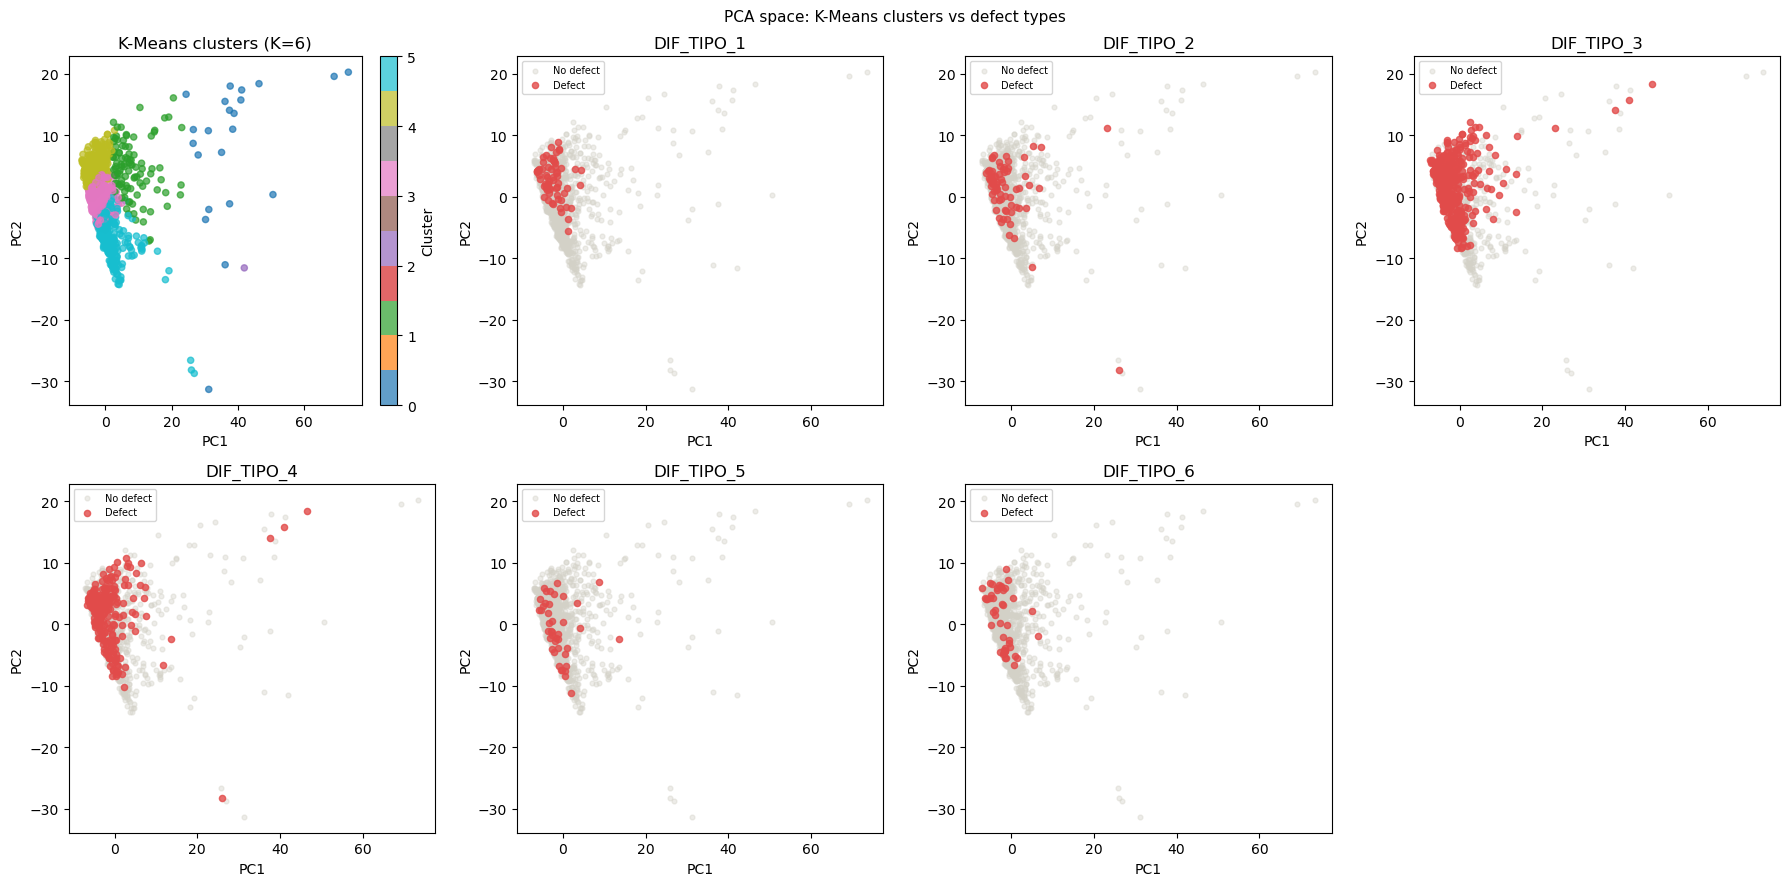

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

# Plot 0: K-Means clusters
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=coil_df['CLUSTER'],
                          cmap='tab10', s=20, alpha=0.7)
axes[0].set_title('K-Means clusters (K=6)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Plots 1-6: one per defect type
for i, col in enumerate(defect_label_cols):
    ax     = axes[i + 1]
    c_vals = y[col].values
    ax.scatter(X_pca[c_vals == 0, 0], X_pca[c_vals == 0, 1],
               c='#D3D1C7', s=12, alpha=0.4, label='No defect')
    ax.scatter(X_pca[c_vals == 1, 0], X_pca[c_vals == 1, 1],
               c='#E24B4A', s=20, alpha=0.8, label='Defect')
    ax.set_title(col.replace('_max',''))
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7)

axes[7].axis('off')

plt.suptitle('PCA space: K-Means clusters vs defect types', fontsize=11)
plt.tight_layout()
plt.show()

## Step 8 — Build Your Data Dictionary
Fill this in based on Steps 5 and 6 — this is the deliverable.

In [24]:
data_dictionary = {
    'DIF_TIPO_1': {
        'prevalence': '5.3% of coils',
        'cluster_association': 'Strongest in Cluster 4 (10%)',
        'sensor_signature': 'High raffination laser + elevated zone 5 combustion',
        'hypothesis': 'Surface defect caused by strip running high post-furnace under elevated zone 5 conditions',
        'confidence': 'Low — only 66 coils, weak cluster signal'
    },
    'DIF_TIPO_2': {
        'prevalence': '5.7% of coils',
        'cluster_association': 'Strongest in Cluster 1 (7%)',
        'sensor_signature': 'High zone 1+2 furnace pressure, lower finishing force',
        'hypothesis': 'Pressure-related surface defect from over-pressurised early furnace zones',
        'confidence': 'Low — only 71 coils, weak cluster signal'
    },
    'DIF_TIPO_3': {
        'prevalence': '34.6% of coils — most common',
        'cluster_association': 'Strongest in Cluster 4 (50%)',
        'sensor_signature': 'High raffination laser + low pre-heat pressure + elevated zone 5',
        'hypothesis': 'Most prevalent defect — likely scale or oxidation driven by raffination strip position and insufficient pre-heating',
        'confidence': 'Medium — 429 coils, clearest cluster signal of all types'
    },
    'DIF_TIPO_4': {
        'prevalence': '19.9% of coils',
        'cluster_association': 'Strongest in Cluster 4 (30%)',
        'sensor_signature': 'Almost always co-occurs with Tipo 3 — same sensor signature',
        'hypothesis': 'Secondary defect that accompanies Tipo 3 — possibly same root cause presenting differently on inspection',
        'confidence': 'Medium — 247 coils, but inseparable from Tipo 3 in sensor space'
    },
    'DIF_TIPO_5': {
        'prevalence': '3.3% of coils — rare',
        'cluster_association': 'Spread across clusters 1, 3, 5 evenly',
        'sensor_signature': 'No dominant sensor pattern identified',
        'hypothesis': 'Rare defect with no clear process driver in PLC data — may depend on material properties or external factors',
        'confidence': 'Very low — only 41 coils, no cluster signal'
    },
    'DIF_TIPO_6': {
        'prevalence': '3.6% of coils — rare',
        'cluster_association': 'Slightly elevated in Cluster 4 (5%)',
        'sensor_signature': 'Weak association with high raffination laser + zone 5 pattern',
        'hypothesis': 'Rare defect loosely associated with same conditions as Tipo 3 and 4',
        'confidence': 'Very low — only 45 coils, very weak signal'
    }
}

print('=' * 60)
print('DATA DICTIONARY — Defect Label Interpretation')
print('Based on K-Means clustering + sensor analysis')
print('=' * 60)

for tipo, info in data_dictionary.items():
    print(f'\n{tipo}')
    print('-' * 40)
    for key, val in info.items():
        print(f'  {key:<25}: {val}')

DATA DICTIONARY — Defect Label Interpretation
Based on K-Means clustering + sensor analysis

DIF_TIPO_1
----------------------------------------
  prevalence               : 5.3% of coils
  cluster_association      : Strongest in Cluster 4 (10%)
  sensor_signature         : High raffination laser + elevated zone 5 combustion
  hypothesis               : Surface defect caused by strip running high post-furnace under elevated zone 5 conditions
  confidence               : Low — only 66 coils, weak cluster signal

DIF_TIPO_2
----------------------------------------
  prevalence               : 5.7% of coils
  cluster_association      : Strongest in Cluster 1 (7%)
  sensor_signature         : High zone 1+2 furnace pressure, lower finishing force
  hypothesis               : Pressure-related surface defect from over-pressurised early furnace zones
  confidence               : Low — only 71 coils, weak cluster signal

DIF_TIPO_3
----------------------------------------
  prevalence          

In [25]:
# Add the overall conclusion
print('\n' + '=' * 60)
print('OVERALL CONCLUSION')
print('=' * 60)
print("""
Key finding: Defect labels do not map cleanly to distinct 
sensor conditions in PLC data.

What sensors CAN predict:
  - Overall defect severity (defective vs clean)
  - Which process regime a coil belongs to (cluster 0-5)
  - High risk conditions: high LASER_RAFF_1 + elevated 
    AIR_Z5/GAS_Z5 + low FRN_PHF_PRESSURE

What sensors CANNOT predict:
  - Which specific Tipo (1-6) will be assigned
  - Rare defects (Tipo 1, 2, 5, 6) with confidence

Recommendation for Phase 2:
  Option A — Binary classification: HAS_DEFECT (0 or 1)
  Option B — Cluster classification: predict cluster 0-5
  Avoid: direct Tipo 1-6 multiclass (sensor signal too weak)
""")


OVERALL CONCLUSION

Key finding: Defect labels do not map cleanly to distinct 
sensor conditions in PLC data.

What sensors CAN predict:
  - Overall defect severity (defective vs clean)
  - Which process regime a coil belongs to (cluster 0-5)
  - High risk conditions: high LASER_RAFF_1 + elevated 
    AIR_Z5/GAS_Z5 + low FRN_PHF_PRESSURE

What sensors CANNOT predict:
  - Which specific Tipo (1-6) will be assigned
  - Rare defects (Tipo 1, 2, 5, 6) with confidence

Recommendation for Phase 2:
  Option A — Binary classification: HAS_DEFECT (0 or 1)
  Option B — Cluster classification: predict cluster 0-5
  Avoid: direct Tipo 1-6 multiclass (sensor signal too weak)



## Step 9 — Save Results

In [26]:
import os
import json
from datetime import date

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Save coil-level cluster assignments ────────────────────
cluster_path = os.path.join(OUTPUT_DIR, 'coil_clusters.csv')
coil_df[['COIL', 'CLUSTER'] + defect_label_cols].to_csv(cluster_path, index=False)
print(f'✅ Coil clusters saved: {cluster_path}')

# ── 2. Save full dataset with cluster assignments ─────────────
df_orig = pd.read_csv(MERGED_PATH)
cluster_map = coil_df[['COIL', 'CLUSTER']]
df_final = df_orig.merge(cluster_map, on='COIL', how='left')
final_path = os.path.join(OUTPUT_DIR, 'merged_with_clusters.csv')
df_final.to_csv(final_path, index=False)
print(f'✅ Full dataset with clusters saved: {final_path}')
print(f'   Shape: {df_final.shape[0]:,} rows × {df_final.shape[1]} cols')

# ── 3. Save data dictionary as JSON ──────────────────────────
dict_path = os.path.join(OUTPUT_DIR, 'data_dictionary.json')
with open(dict_path, 'w') as f:
    json.dump(data_dictionary, f, indent=2)
print(f'✅ Data dictionary saved: {dict_path}')

# ── 4. Save PCA + cluster summary stats ──────────────────────
summary_rows = []
for cid in sorted(coil_df['CLUSTER'].unique()):
    mask         = coil_df['CLUSTER'] == cid
    subset_y     = y[mask.values]
    cluster_mean = coil_df[mask][mean_sensor_cols].mean()
    overall_mean = coil_df[mean_sensor_cols].mean()
    pct_diff     = ((cluster_mean - overall_mean) / (overall_mean.abs() + 1e-6)) * 100
    top3         = pct_diff.abs().nlargest(3)
    
    row = {
        'cluster': cid,
        'n_coils': int(mask.sum()),
        'top_sensors': ', '.join([s.replace('_mean','') for s in top3.index]),
    }
    for col in defect_label_cols:
        row[col.replace('_max','').replace('DIF_','')] = f"{subset_y[col].mean()*100:.0f}%"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUTPUT_DIR, 'cluster_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f'✅ Cluster summary saved: {summary_path}')

print(f'\n✅ All outputs saved to: {OUTPUT_DIR}')
print(f'   Files: coil_clusters.csv, merged_with_clusters.csv,')
print(f'          data_dictionary.json, cluster_summary.csv')

✅ Coil clusters saved: ../data/final\coil_clusters.csv
✅ Full dataset with clusters saved: ../data/final\merged_with_clusters.csv
   Shape: 298,851 rows × 121 cols
✅ Data dictionary saved: ../data/final\data_dictionary.json
✅ Cluster summary saved: ../data/final\cluster_summary.csv

✅ All outputs saved to: ../data/final
   Files: coil_clusters.csv, merged_with_clusters.csv,
          data_dictionary.json, cluster_summary.csv
